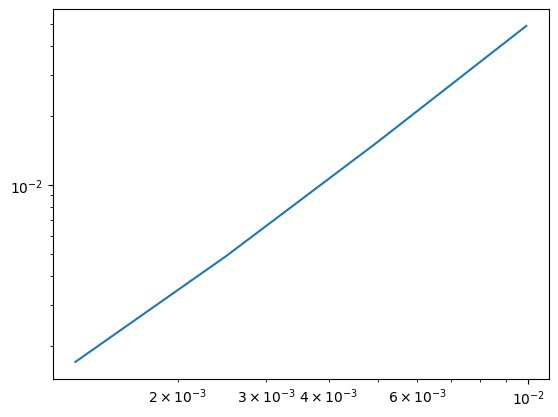

In [1]:
#Projet methodes numériques: Equation des ondes

import numpy as np
import math as math
import matplotlib.pyplot as plt

#On definit d'abord la fonction au temps initial u0

def u0(x):
    a=0.2
    if x<=a and -a<=x:
        return ((1-(x/a)**2)**2) * (1 - 2*(x/a)**2)
    else:
        return 0

#On peut maintenant definir la fonction pour tout x dans ]-1,1[ et t dans ]0,1[

def u(x,t):
    c=1/2
    return (1/2) * ( u0(x-c*t) + u0(x+c*t))


#Voyons la representation graphique de notre solution au temps 0.5

V = np.array([-1. , -0.8 , -0.6 , -0.4 , -0.2 , 0 , 0.2 , 0.4 , 0.6 , 0.8])
U = np.zeros(10) 

t=0.8

for i in range(10):
    U[i] = u( V[i] , 1)

#plt.plot(V,U)


#On va maintenant stocker les valeurs de u pour un temps T et un point X de l'espace dans un tableau de dimension Nt par Nx

def wave1d(Nt,Nx):
    
    dx=2/(Nx-1)
    dt=1/(Nt-1)
    r = ((1/2) * dt / dx)**2
    
    #On defini le vecteur contenant les points de la discrétisation en espace
    
    X=np.zeros(Nx)
    for i in range(Nx):        
        X[i] = -1 + i*dx

    #On cree maintenant le tableau qui va stocker les valeurs de notre approximation au cours du temps et de l'espace
    
    Tableau_valeur_de_u = np.zeros((Nt ,Nx))

    #La premiere et la seconde ligne de notre matrice sera les valeurs de la solution initiale
    
    for j in range(Nx):
      
        Tableau_valeur_de_u[0,j] = u0(X[j])
        Tableau_valeur_de_u[1,j] = u0(X[j])

    #On implémente les conditions au bords

    for i in range(0,Nt):
        Tableau_valeur_de_u[i,0] = 0
        Tableau_valeur_de_u[i,Nx-1] = 0

    #Calculons maintenant les solution approximees aux differents temps et implementons les dans la matrice

    for i in range(1,Nt-1):

        for j in range(1,Nx-1):
             
             Tableau_valeur_de_u[i+1,j] = 2 * Tableau_valeur_de_u[i,j] -  Tableau_valeur_de_u[i-1,j] + r * ( Tableau_valeur_de_u[i , j-1] - 2 * Tableau_valeur_de_u[i , j] +  Tableau_valeur_de_u[i ,j+1] )   

    return Tableau_valeur_de_u

#plt.plot(V,wave1d(10,10)[8])

#On calcule maintenant l'erreur au temps 1-(1/Nt)

def erreur_finale_Nt(Nt):
    Nx=int((1/2)*Nt)
    dx=2/(Nx-1)
    dt=1/(Nt-1)
    S=0
    solution_approx=wave1d(Nt,Nx)
    for j in range(0,Nx):
      
        S= S + (solution_approx[Nt-1,j] - u( -1 + j*dx , 1))**2

    S=(dx*S)**(1/2)
    
    return S

#On construit les vecteurs contenants les valeurs de Delta_t et les erreurs associées

Delta_t = np.array([1/101,1/201,1/401,1/801])

Vect_err_Nt = np.array([erreur_finale_Nt(101),erreur_finale_Nt(201),erreur_finale_Nt(401),erreur_finale_Nt(801)])

#Representation graphique de l'erreur en fonction de la discretisation en espace

plt.loglog(Delta_t, Vect_err_Nt)

